**Name**: Devyani Sanjay Gurgude **Div**: SEDA **Roll**: 09 **PRN no**:1252090009

**Assignment No: 11**

Assignment on Classification technique. Every year many students give the GRE exam to get admission in foreign Universities. The data set contains GRE Scores (out of 340), TOEFL Scores (out of 120), University Rating (out of 5), Statement of Purpose strength (out of 5), Letter of Recommendation strength (out of 5), Undergraduate GPA (out of 10), Research Experience (0=no, 1=yes), Admitted (0=no, 1=yes). Admitted is the target variable.

Data Set: https://www.kaggle.com/mohansacharya/graduate-admissions

The counsellor of the firm is supposed check whether the student will get an admission or not based on his/her GRE score and Academic Score. So to help the counsellor to make appropriate decisions, build a machine learning model classifier using a Decision tree to predict whether a student will get admission or not.  Apply Data pre-processing (Label Encoding, Data Transformation….) techniques if necessary.

1. Perform data-preparation (Train-Test Split)

2. Apply Machine Learning Algorithm

3. Evaluate Model.

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report , confusion_matrix

data = pd.read_csv("Admission_Predict.csv")
print(data.head())

   Serial No.  GRE Score  TOEFL Score  University Rating  SOP  LOR   CGPA  \
0           1        337          118                  4  4.5   4.5  9.65   
1           2        324          107                  4  4.0   4.5  8.87   
2           3        316          104                  3  3.0   3.5  8.00   
3           4        322          110                  3  3.5   2.5  8.67   
4           5        314          103                  2  2.0   3.0  8.21   

   Research  Chance of Admit   
0         1              0.92  
1         1              0.76  
2         1              0.72  
3         1              0.80  
4         0              0.65  


Data Preprocessing

In [ ]:
print(data.isnull().sum())
X = data[['GRE Score', 'CGPA']]
y = data['Chance of Admit ']
y = (y > 0.5).astype(int)

Serial No.           0
GRE Score            0
TOEFL Score          0
University Rating    0
SOP                  0
LOR                  0
CGPA                 0
Research             0
Chance of Admit      0
dtype: int64


Train-Test Split and Apply Decision Tree Model

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = DecisionTreeClassifier( criterion='gini',max_depth=4,random_state=42)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

result_df = X_test.copy()
result_df['Actual_Admitted'] = y_test
result_df['Predicted_Admitted'] = y_pred

print(result_df.head(10))

     GRE Score  CGPA  Actual_Admitted  Predicted_Admitted
209        301  8.12                1                   1
280        311  8.64                1                   1
33         340  9.60                1                   1
210        325  9.06                1                   1
93         301  7.88                0                   1
84         340  9.45                1                   1
329        297  7.89                0                   1
94         303  7.66                0                   0
266        312  8.45                1                   1
126        323  9.32                1                   1


Evaluate Model

In [ ]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.875

Classification Report:

              precision    recall  f1-score   support

           0       0.50      0.40      0.44        10
           1       0.92      0.94      0.93        70

    accuracy                           0.88        80
   macro avg       0.71      0.67      0.69        80
weighted avg       0.86      0.88      0.87        80


Confusion Matrix:

[[ 4  6]
 [ 4 66]]


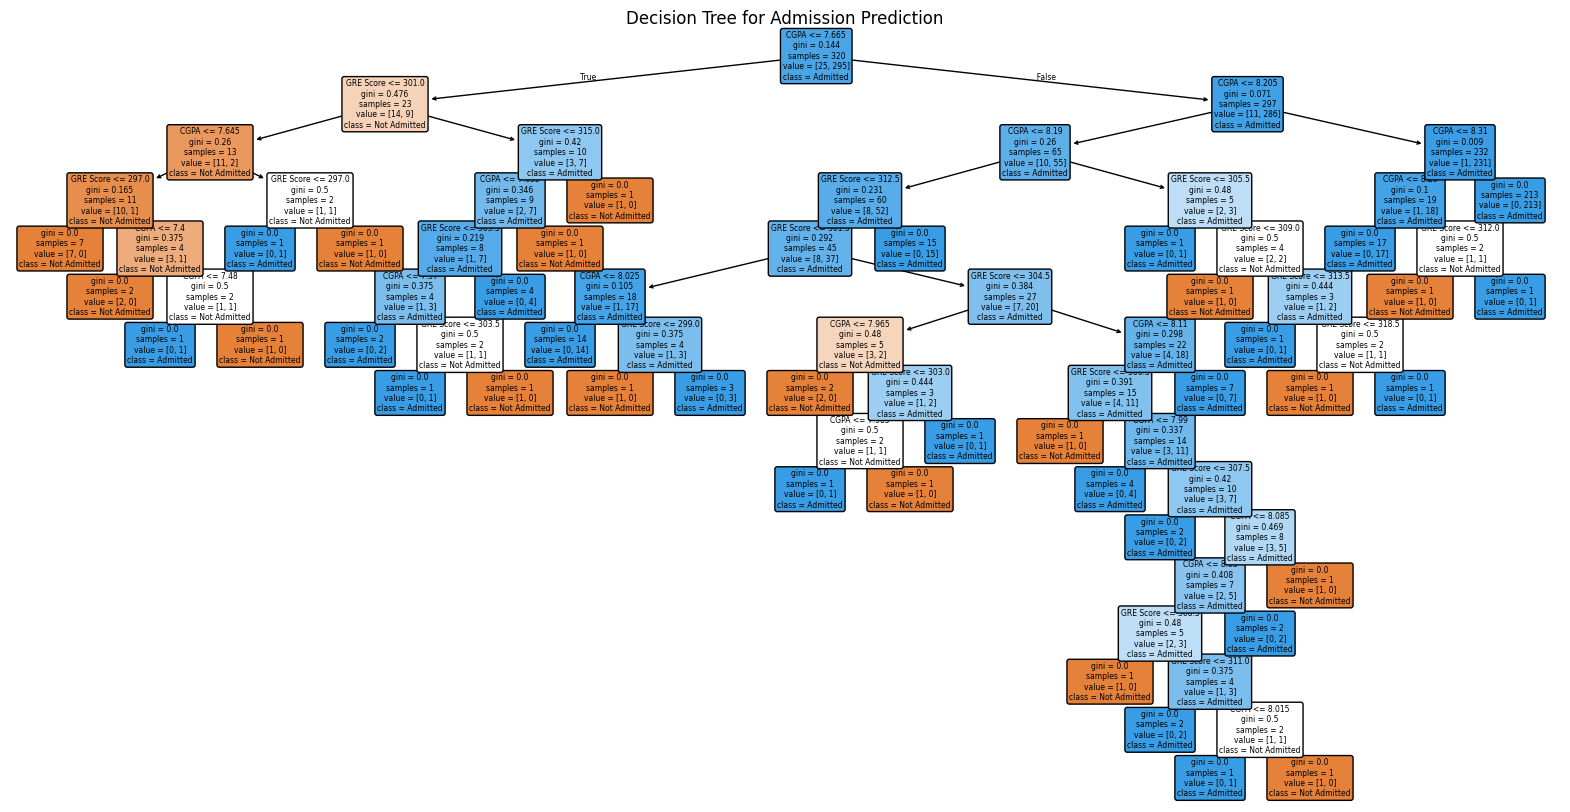

In [ ]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(20,10))
plot_tree(model, filled=True, feature_names=X.columns.tolist(), class_names=['Not Admitted', 'Admitted'], rounded=True)
plt.title("Decision Tree for Admission Prediction")
plt.show()

Random Forest

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

model = RandomForestClassifier(criterion='entropy',max_depth=5,random_state=42)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

result_df = X_test.copy()
result_df['Actual_Admitted'] = y_test
result_df['Predicted_Admitted'] = y_pred

print(result_df.head(10))

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))

     GRE Score  CGPA  Actual_Admitted  Predicted_Admitted
209        301  8.12                1                   1
280        311  8.64                1                   1
33         340  9.60                1                   1
210        325  9.06                1                   1
93         301  7.88                0                   1
84         340  9.45                1                   1
329        297  7.89                0                   1
94         303  7.66                0                   1
266        312  8.45                1                   1
126        323  9.32                1                   1
Accuracy: 0.9

Classification Report:

              precision    recall  f1-score   support

           0       0.75      0.30      0.43        10
           1       0.91      0.99      0.95        70

    accuracy                           0.90        80
   macro avg       0.83      0.64      0.69        80
weighted avg       0.89      0.90      0.88        